In [1]:
#Importing Libraries

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
sns.set_style("whitegrid")

In [2]:
#Load Data
df = pd.read_csv('/content/test.csv')
df.head()


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [3]:
#Cleaning
df = df.drop(columns=[c for c in ['Unnamed: 0', 'id'] if c in df.columns])
df = df.drop_duplicates()
print(df.isnull().sum())
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())
df.columns = df.columns.str.strip().str.replace(' ', '_')


Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0
dtype: int64


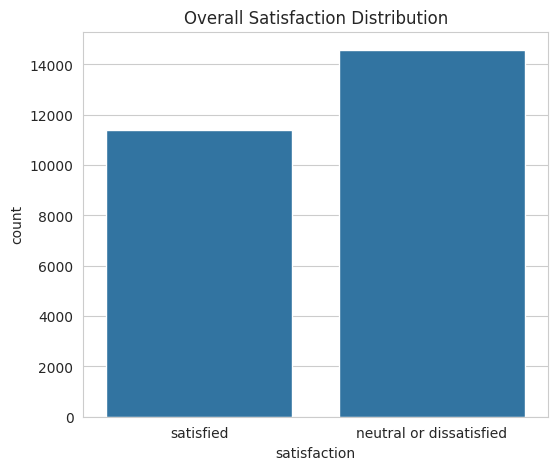

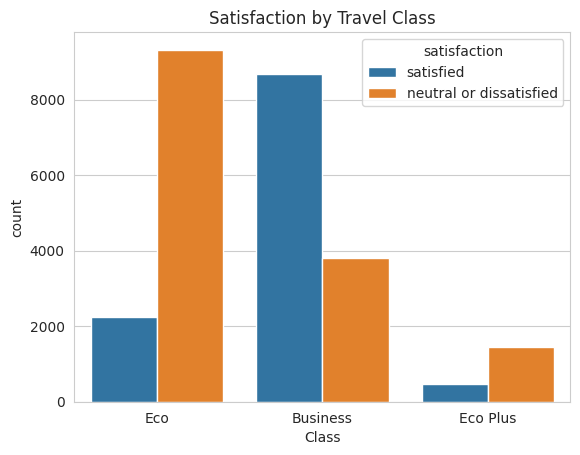

In [4]:
#EDA: Satisfaction Breakdown
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='satisfaction')
plt.title('Overall Satisfaction Distribution')
plt.show()

sns.countplot(data=df, x='Class', hue='satisfaction')
plt.title('Satisfaction by Travel Class')
plt.show()

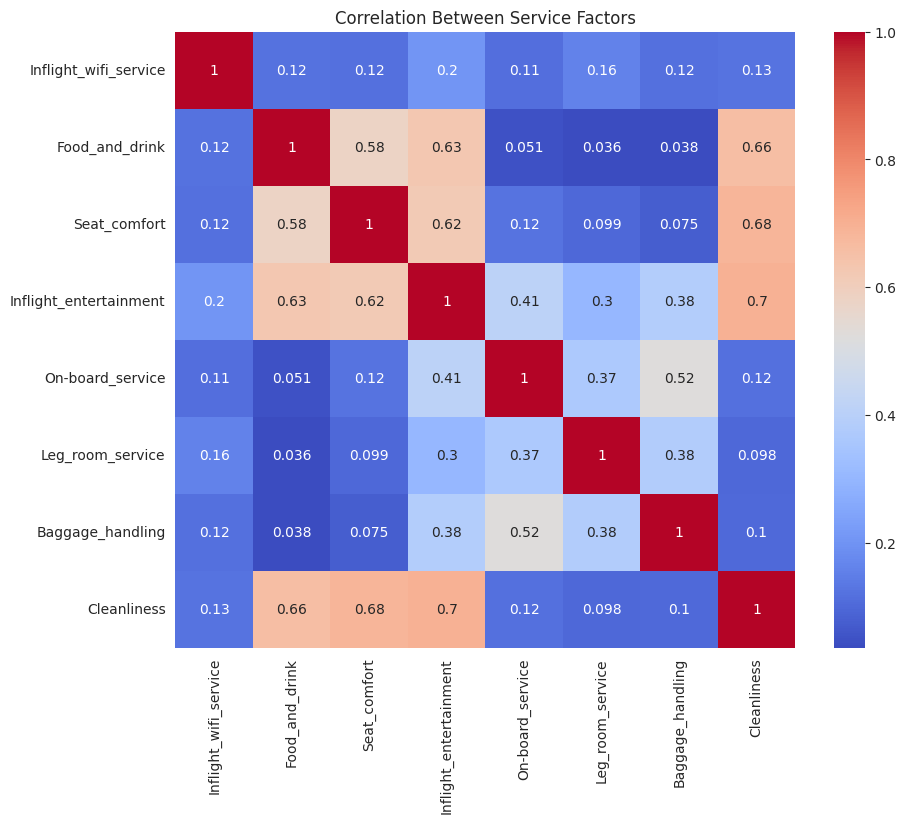

In [5]:
#EDA: Service Factor Correlation
service_cols = ['Inflight_wifi_service','Food_and_drink','Seat_comfort',
                 'Inflight_entertainment','On-board_service','Leg_room_service',
                 'Baggage_handling','Cleanliness']
service_cols = [c for c in service_cols if c in df.columns]

plt.figure(figsize=(10,8))
sns.heatmap(df[service_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Service Factors')
plt.show()

In [6]:
#Statistical Test: Delay vs Satisfaction
satisfied = df[df['satisfaction']=='satisfied']['Departure_Delay_in_Minutes']
neutral_diss = df[df['satisfaction']!='satisfied']['Departure_Delay_in_Minutes']

t_stat, p_val = stats.ttest_ind(satisfied, neutral_diss, equal_var=False)
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.5f}")
print("Statistically significant difference" if p_val < 0.05 else "No significant difference")

T-statistic: -8.517, P-value: 0.00000
Statistically significant difference


In [7]:
#A/B-Style Test: Class vs Satisfaction (Chi-Square)
contingency = pd.crosstab(df['Class'], df['satisfaction'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square: {chi2:.2f}, P-value: {p:.5f}")

Chi-square: 6435.04, P-value: 0.00000


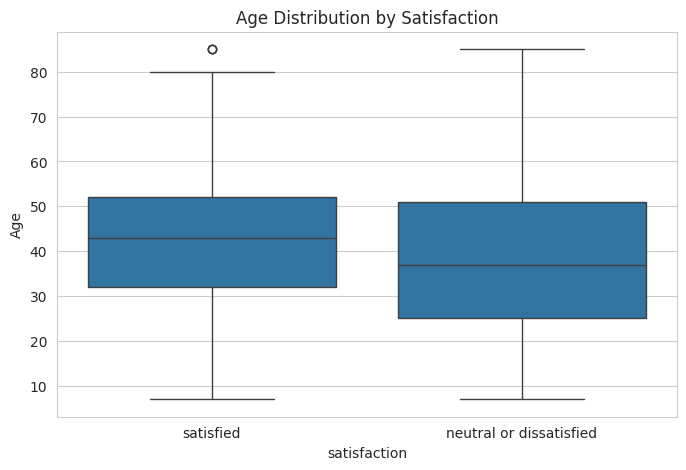

In [8]:
#Age Distribution by Satisfaction
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='satisfaction', y='Age')
plt.title('Age Distribution by Satisfaction')
plt.show()